In [1]:
import numpy as np 
import pandas as pd

In [2]:
base_path = "../data_corr_0.5_negative_10000_no_gene_expr_03_12/"

In [3]:
nedbit_path = "df_nebit_dnam_features_aml_PNA.csv"
df_nebit_features = pd.read_csv(base_path + nedbit_path, sep=",")
df_nebit_features

,name,degree,ring,NetRank,NetShort,HeatDiff,InfoDiff,0,1,2,...,47,48,49,50,51,52,53,54,55,labels
0,cg01833436_SDCCAG8,485,1,0.460286,4.742593e+02,9.346998e-01,5.254281e-01,0.835195,0.872817,0.789144,...,0.485280,0.604581,0.664450,0.555493,0.618902,0.644076,0.501210,0.724217,0.662135,1
1,cg01833436_AKT3,485,1,0.460286,4.742593e+02,9.346998e-01,5.254281e-01,0.835195,0.872817,0.789144,...,0.485280,0.604581,0.664450,0.555493,0.618902,0.644076,0.501210,0.724217,0.662135,1
2,cg22032366_HMGN3,482,2,1.693515,3.289672e+02,1.332551e-01,4.415517e-01,0.879386,0.911101,0.854212,...,0.571809,0.666165,0.762096,0.657395,0.699611,0.751059,0.613318,0.755883,0.715016,2
3,cg12924525_TSSC1,489,1,0.489997,4.580892e+02,8.699467e-01,5.175575e-01,0.801935,0.861178,0.765236,...,0.524293,0.568173,0.639811,0.599169,0.644641,0.648042,0.524254,0.700529,0.670761,1
4,cg00703120_PCCA,478,1,0.456544,4.732502e+02,9.369633e-01,5.362387e-01,0.809946,0.843215,0.776268,...,0.475718,0.571522,0.618152,0.538740,0.629927,0.634550,0.516613,0.669428,0.619656,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10272,cg26473478_C6orf136,10,6,5.999997,3.137596e+01,1.028031e-12,2.304007e-10,0.030067,0.018948,0.056831,...,0.001469,0.016951,0.016517,0.034877,0.031303,0.022002,0.008327,0.040323,0.019936,5
10273,cg06789048_RGS12,1,4,3.976885,3.969504e+01,2.429658e-07,7.632322e-07,0.840696,0.882677,0.000000,...,0.880158,0.837297,0.861179,0.807062,0.793773,0.891627,0.856434,0.782554,0.779546,3
10274,cg20800956_DNM3,2,7,7.000000,3.411553e+01,3.546262e-17,5.131442e-14,0.029457,0.046394,0.056969,...,0.107603,0.040202,0.020819,0.074469,0.029248,0.036274,0.043836,0.030616,0.018803,5
10275,cg22813794_STYXL1,1,0,0.000000,5.716215e-305,0.000000e+00,0.000000e+00,0.028215,0.026707,0.035239,...,0.022892,0.016971,0.022287,0.041879,0.039479,0.019991,0.133638,0.030438,0.018032,1


In [4]:
df_degree_labels = df_nebit_features[["degree", "labels"]]
df_degree_labels

,degree,labels
0,485,1
1,485,1
2,482,2
3,489,1
4,478,1
...,...,...
10272,10,5
10273,1,3
10274,2,5
10275,1,1


{1: 134574, 2: 831345, 4: 4437397, 5: 4868512, 3: 1920136}


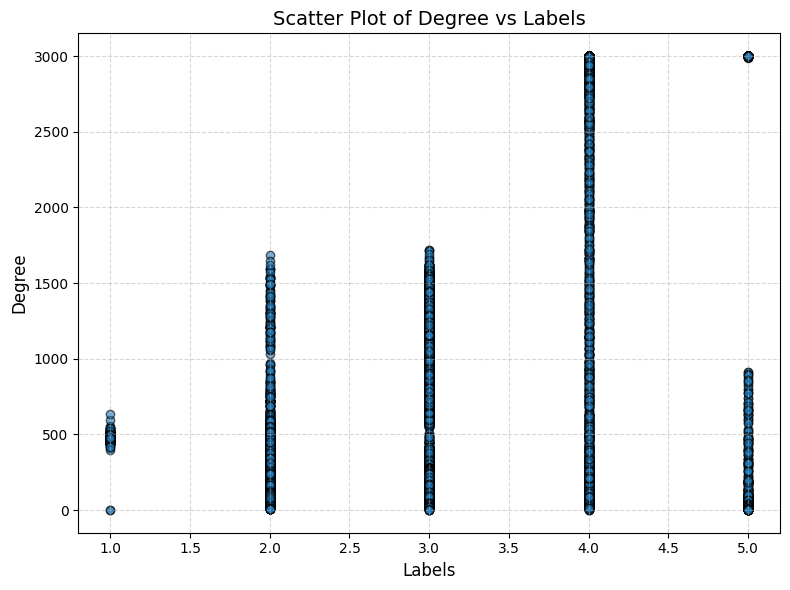

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

data = {
    'degree': df_degree_labels["degree"].tolist(),
    'labels': df_degree_labels["labels"].tolist(),
}
df = pd.DataFrame(data)

agg_dict = {}

for index, row in df.iterrows():
    if row["labels"] not in agg_dict:
        agg_dict[row["labels"]] = int(row["degree"])
    else:
        agg_dict[row["labels"]] += row["degree"]

print(agg_dict)

# Create scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(df['labels'], df['degree'], alpha=0.6, edgecolor='k')

# Add labels and title
plt.xlabel("Labels", fontsize=12)
plt.ylabel("Degree", fontsize=12)
plt.title("Scatter Plot of Degree vs Labels", fontsize=14)

# Optional: grid and styling
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# Show plot
plt.show()

       degree  labels
0         485       1
1         485       1
2         482       2
3         489       1
4         478       1
...       ...     ...
10272      10       5
10273       1       3
10274       2       5
10275       1       1
10276       1       1

[10277 rows x 2 columns]
   labels         mean  median
0       1   477.212766   479.0
1       2   306.317244   244.5
2       3   707.753778   658.0
3       4  1765.776761  2340.0
4       5  2369.105596  3000.0


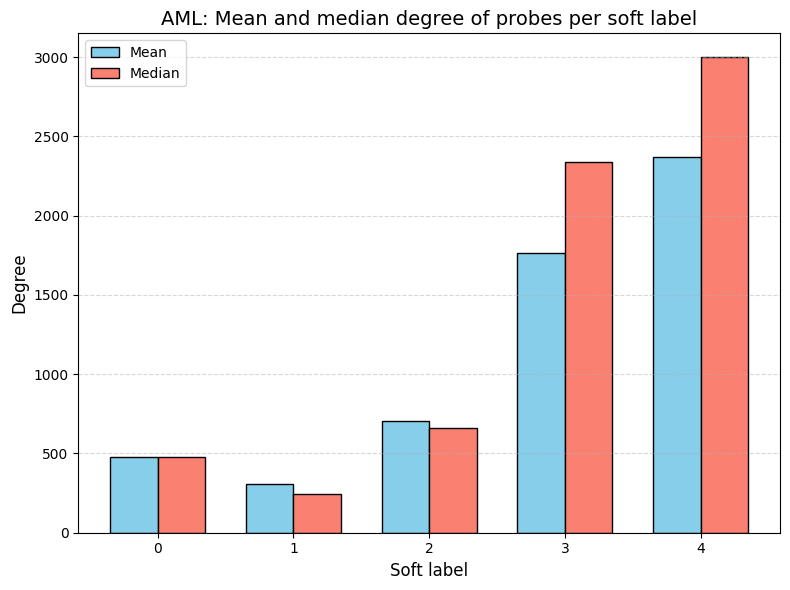

In [13]:
# Example: load data (adjust path as needed)
# df = pd.read_csv("data.csv", sep="\t")  # if tab-separated
# or if it's already in memory:
data = {
    'degree': df_degree_labels["degree"].tolist(),
    'labels': df_degree_labels["labels"].tolist(),
}
df = pd.DataFrame(data)

print(df)

grouped = df.groupby('labels')['degree'].agg(['mean', 'median']).reset_index()

print(grouped)

# --- Plot ---
plt.figure(figsize=(8, 6))

# Plot mean and median as grouped bars
width = 0.35
x = range(len(grouped))

plt.bar([i - width/2 for i in x], grouped['mean'], width=width, label='Mean', color='skyblue', edgecolor='k')
plt.bar([i + width/2 for i in x], grouped['median'], width=width, label='Median', color='salmon', edgecolor='k')

# --- Labels and styling ---
plt.xticks(x, grouped['labels'] - 1)
plt.xlabel('Soft label', fontsize=12)
plt.ylabel('Degree', fontsize=12)
plt.title('AML: Mean and median degree of probes per soft label', fontsize=14)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

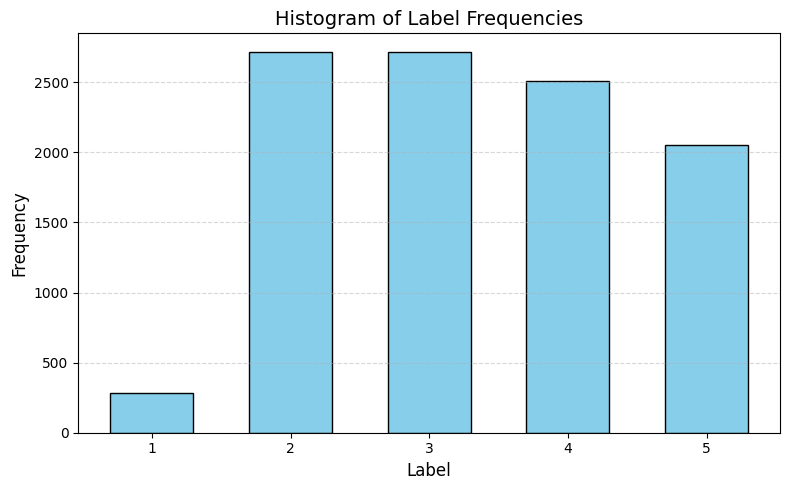

In [7]:
# Example: load data (adjust path as needed)
# df = pd.read_csv("data.csv", sep="\t")  # if tab-separated
# or if it's already in memory:
data = {
    'degree': df_degree_labels["degree"].tolist(),
    'labels': df_degree_labels["labels"].tolist(),
}
df = pd.DataFrame(data)

# --- Compute frequency of each label ---
label_counts = df['labels'].value_counts().sort_index()

# --- Plot histogram / bar plot ---
plt.figure(figsize=(8, 5))
plt.bar(label_counts.index, label_counts.values, color='skyblue', edgecolor='black', width=0.6)

# --- Labels and formatting ---
plt.xlabel("Label", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.title("Histogram of Label Frequencies", fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
